ESCENARIO 02 CHAT GPT - SIN REGLAS, VERSIÓN PAGA


RESULTADOS DEL CONTROL DE AVANCE DE LA OBRA

1. AVANCE DE CADA ACTIVIDAD
----------------------------------------------------------------------
ID: STAP-CIV-001 | Avance: 96.76%
ID: STAP-CIV-002 | Avance: 97.80%
ID: STAP-CIV-003 | Avance: 79.33%
ID: STAP-CIV-004 | Avance: 82.04%
ID: STAP-CIV-005 | Avance: 100.00%
ID: STAP-CIV-006 | Avance: 85.13%
ID: STAP-CIV-007 | Avance: 87.16%
ID: STAP-CIV-008 | Avance: 78.00%
ID: STAP-CIV-009 | Avance: 76.88%
ID: STAP-CIV-010 | Avance: 95.27%
ID: STAP-CIV-011 | Avance: 86.27%
ID: STAP-CIV-012 | Avance: 94.07%
ID: STAP-CIV-013 | Avance: 88.70%
ID: STAP-CIV-014 | Avance: 79.36%
ID: STAP-CIV-015 | Avance: 82.99%
ID: STAP-CIV-016 | Avance: 95.23%
ID: STAP-CIV-017 | Avance: 75.00%
ID: STAP-CIV-018 | Avance: 84.55%
ID: STAP-CIV-019 | Avance: 80.30%
ID: STAP-CIV-020 | Avance: 93.80%
ID: STAP-CIV-021 | Avance: 89.36%
ID: STAP-CIV-022 | Avance: 92.21%
ID: STAP-CIV-023 | Avance: 94.77%
ID: STAP-CIV-024 | Avance: 77.30%
ID: STAP-CIV-025 | Avance: 84.60%
ID: 

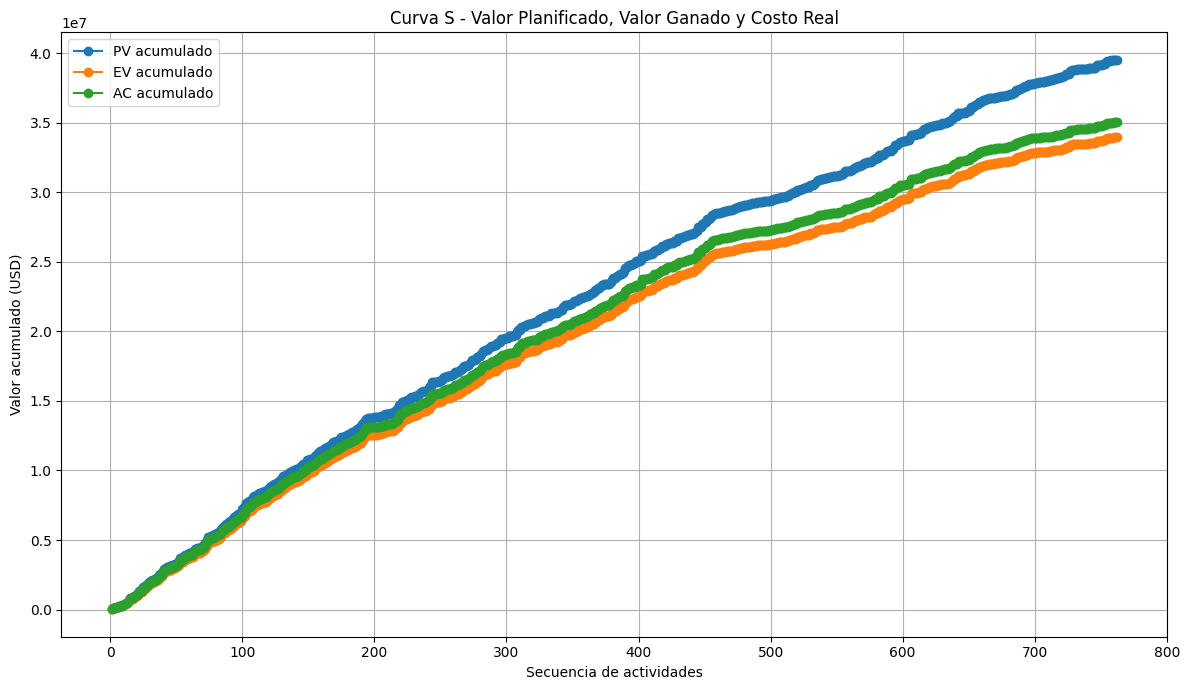

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CASO 2 - CONTROL DE AVANCE FÍSICO Y VALOR GANADO (EVM)
# ============================================================

ARCHIVO = "02_Dataset_Base_STAP.csv"

UNIDADES_VALIDAS = {
    "pulg_diam",
    "kg",
    "m",
    "m2",
    "m3",
    "und"
}

DISCIPLINAS_VALIDAS = {
    "Civil",
    "Mecánica estática",
    "Rotativa",
    "Instrumentación",
    "Eléctrica"
}

COLUMNAS_REQUERIDAS = [
    "id_actividad",
    "disciplina",
    "descripcion",
    "unidad",
    "cantidad_planificada",
    "cantidad_ejecutada",
    "peso_presupuesto_usd",
    "avance_planificado_pct",
    "costo_real_usd"
]


# ============================================================
# 1. LECTURA DEL ARCHIVO
# ============================================================

try:
    df = pd.read_csv(ARCHIVO, encoding="utf-8", sep=",")
except Exception as error:
    print(f"ERROR: No fue posible leer el archivo '{ARCHIVO}'.")
    print(f"Detalle: {error}")
    df = pd.DataFrame(columns=COLUMNAS_REQUERIDAS)


# ============================================================
# 2. VERIFICACIÓN DE COLUMNAS
# ============================================================

columnas_faltantes = [
    columna for columna in COLUMNAS_REQUERIDAS
    if columna not in df.columns
]

if columnas_faltantes:
    print("\nADVERTENCIA: Faltan columnas requeridas:")
    for columna in columnas_faltantes:
        print(f"- {columna}")

    # Se crean las columnas faltantes para evitar detener el programa.
    for columna in columnas_faltantes:
        df[columna] = pd.NA


# ============================================================
# 3. NORMALIZACIÓN DE DATOS NUMÉRICOS
# ============================================================

columnas_numericas = [
    "cantidad_planificada",
    "cantidad_ejecutada",
    "peso_presupuesto_usd",
    "avance_planificado_pct",
    "costo_real_usd"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")


# ============================================================
# 4. VALIDACIONES
# ============================================================

inconsistencias = []

for indice, fila in df.iterrows():

    id_actividad = fila["id_actividad"]

    if pd.isna(id_actividad):
        id_actividad = f"Fila_{indice + 2}"

    # --------------------------------------------------------
    # Cantidad ejecutada mayor que cantidad planificada
    # --------------------------------------------------------
    if (
        pd.notna(fila["cantidad_ejecutada"])
        and pd.notna(fila["cantidad_planificada"])
        and fila["cantidad_ejecutada"] > fila["cantidad_planificada"]
    ):
        inconsistencias.append(
            {
                "id_actividad": id_actividad,
                "inconsistencia":
                    "Cantidad ejecutada mayor que la cantidad planificada."
            }
        )

    # --------------------------------------------------------
    # Peso presupuestal nulo, negativo o ausente
    # --------------------------------------------------------
    if (
        pd.isna(fila["peso_presupuesto_usd"])
        or fila["peso_presupuesto_usd"] <= 0
    ):
        inconsistencias.append(
            {
                "id_actividad": id_actividad,
                "inconsistencia":
                    "Peso presupuestal nulo, negativo o ausente."
            }
        )

    # --------------------------------------------------------
    # Unidad no reconocida
    # --------------------------------------------------------
    if (
        pd.isna(fila["unidad"])
        or str(fila["unidad"]).strip() not in UNIDADES_VALIDAS
    ):
        inconsistencias.append(
            {
                "id_actividad": id_actividad,
                "inconsistencia":
                    f"Unidad no reconocida: '{fila['unidad']}'."
            }
        )

    # --------------------------------------------------------
    # Disciplina no reconocida
    # --------------------------------------------------------
    if (
        pd.isna(fila["disciplina"])
        or str(fila["disciplina"]).strip() not in DISCIPLINAS_VALIDAS
    ):
        inconsistencias.append(
            {
                "id_actividad": id_actividad,
                "inconsistencia":
                    f"Disciplina no reconocida: '{fila['disciplina']}'."
            }
        )

    # --------------------------------------------------------
    # Avance planificado fuera del rango [0, 1]
    # --------------------------------------------------------
    if (
        pd.isna(fila["avance_planificado_pct"])
        or fila["avance_planificado_pct"] < 0
        or fila["avance_planificado_pct"] > 1
    ):
        inconsistencias.append(
            {
                "id_actividad": id_actividad,
                "inconsistencia":
                    "Avance planificado fuera del rango [0, 1] o ausente."
            }
        )


# ------------------------------------------------------------
# ID de actividad duplicado
# ------------------------------------------------------------

duplicados = df[
    df["id_actividad"].notna()
    & df["id_actividad"].duplicated(keep=False)
]

for _, fila in duplicados.iterrows():
    inconsistencias.append(
        {
            "id_actividad": fila["id_actividad"],
            "inconsistencia": "ID de actividad duplicado."
        }
    )


# ============================================================
# 5. PREPARACIÓN DE DATOS PARA LOS CÁLCULOS
# ============================================================

# Se crean columnas auxiliares sin modificar los datos originales.
df["cantidad_planificada_calc"] = (
    df["cantidad_planificada"].fillna(0)
)

df["cantidad_ejecutada_calc"] = (
    df["cantidad_ejecutada"].fillna(0)
)

df["peso_calc"] = (
    df["peso_presupuesto_usd"]
    .fillna(0)
    .clip(lower=0)
)

df["avance_planificado_calc"] = (
    df["avance_planificado_pct"]
    .fillna(0)
    .clip(lower=0, upper=1)
)

df["costo_real_calc"] = (
    df["costo_real_usd"]
    .fillna(0)
    .clip(lower=0)
)


# ============================================================
# 6. AVANCE DE CADA ACTIVIDAD
# ============================================================

def calcular_avance_actividad(fila):
    """
    Avance actividad =
    cantidad ejecutada / cantidad planificada.

    El resultado se limita al rango [0, 1].
    """

    cantidad_planificada = fila["cantidad_planificada_calc"]
    cantidad_ejecutada = fila["cantidad_ejecutada_calc"]

    if cantidad_planificada > 0:
        avance = cantidad_ejecutada / cantidad_planificada
        return max(0, min(avance, 1))

    return 0


df["avance_actividad"] = df.apply(
    calcular_avance_actividad,
    axis=1
)


# ============================================================
# 7. AVANCE FÍSICO CONSOLIDADO
# ============================================================

peso_total = df["peso_calc"].sum()

if peso_total > 0:

    avance_fisico_consolidado = (
        (
            df["avance_actividad"]
            * df["peso_calc"]
        ).sum()
        / peso_total
    )

else:
    avance_fisico_consolidado = 0


# ============================================================
# 8. AVANCE POR DISCIPLINA
# ============================================================

avance_por_disciplina = {}

for disciplina, grupo in df.groupby("disciplina", dropna=False):

    peso_disciplina = grupo["peso_calc"].sum()

    if peso_disciplina > 0:

        avance = (
            (
                grupo["avance_actividad"]
                * grupo["peso_calc"]
            ).sum()
            / peso_disciplina
        )

    else:
        avance = 0

    avance_por_disciplina[disciplina] = avance


# ============================================================
# 9. CÁLCULO DE VALOR GANADO - EVM
# ============================================================

# PV = Planned Value
# Valor presupuestado del trabajo que debería haberse ejecutado.

df["PV"] = (
    df["peso_calc"]
    * df["avance_planificado_calc"]
)

# EV = Earned Value
# Valor presupuestado correspondiente al avance realmente ejecutado.

df["EV"] = (
    df["peso_calc"]
    * df["avance_actividad"]
)

# AC = Actual Cost
# Costo real registrado.

df["AC"] = df["costo_real_calc"]


PV = df["PV"].sum()
EV = df["EV"].sum()
AC = df["AC"].sum()


# ============================================================
# 10. INDICADORES SPI Y CPI
# ============================================================

# SPI = EV / PV

if PV > 0:
    SPI = EV / PV
else:
    SPI = None


# CPI = EV / AC

if AC > 0:
    CPI = EV / AC
else:
    CPI = None


# ============================================================
# 11. INTERPRETACIÓN DE SPI
# ============================================================

if SPI is None:
    interpretacion_spi = (
        "SPI no calculable porque el PV es igual a cero."
    )

elif SPI > 1:
    interpretacion_spi = (
        "La obra presenta adelanto respecto al avance planificado."
    )

elif SPI < 1:
    interpretacion_spi = (
        "La obra presenta atraso respecto al avance planificado."
    )

else:
    interpretacion_spi = (
        "La obra se encuentra exactamente de acuerdo con "
        "el avance planificado."
    )


# ============================================================
# 12. INTERPRETACIÓN DE CPI
# ============================================================

if CPI is None:
    interpretacion_cpi = (
        "CPI no calculable porque el costo real AC es igual a cero."
    )

elif CPI > 1:
    interpretacion_cpi = (
        "La obra presenta ahorro o desempeño favorable en costos."
    )

elif CPI < 1:
    interpretacion_cpi = (
        "La obra presenta sobrecosto o desempeño desfavorable en costos."
    )

else:
    interpretacion_cpi = (
        "La obra se encuentra exactamente de acuerdo con "
        "el presupuesto ejecutado."
    )


# ============================================================
# 13. RESULTADOS POR PANTALLA
# ============================================================

print("\n" + "=" * 70)
print("RESULTADOS DEL CONTROL DE AVANCE DE LA OBRA")
print("=" * 70)


# ------------------------------------------------------------
# Avance de cada actividad
# ------------------------------------------------------------

print("\n1. AVANCE DE CADA ACTIVIDAD")
print("-" * 70)

for _, fila in df.iterrows():

    print(
        f"ID: {fila['id_actividad']} | "
        f"Avance: {fila['avance_actividad'] * 100:.2f}%"
    )


# ------------------------------------------------------------
# Avance físico consolidado
# ------------------------------------------------------------

print("\n2. AVANCE FÍSICO CONSOLIDADO")
print("-" * 70)

print(
    f"Avance físico consolidado: "
    f"{avance_fisico_consolidado * 100:.2f}%"
)


# ------------------------------------------------------------
# Avance por disciplina
# ------------------------------------------------------------

print("\n3. AVANCE POR DISCIPLINA")
print("-" * 70)

for disciplina, avance in avance_por_disciplina.items():

    print(
        f"{disciplina}: "
        f"{avance * 100:.2f}%"
    )


# ------------------------------------------------------------
# Indicadores EVM
# ------------------------------------------------------------

print("\n4. INDICADORES DE VALOR GANADO (EVM)")
print("-" * 70)

print(f"PV - Planned Value:  USD {PV:,.2f}")
print(f"EV - Earned Value:   USD {EV:,.2f}")
print(f"AC - Actual Cost:    USD {AC:,.2f}")

if SPI is not None:
    print(f"SPI: {SPI:.3f}")
else:
    print("SPI: No calculable")

if CPI is not None:
    print(f"CPI: {CPI:.3f}")
else:
    print("CPI: No calculable")


# ------------------------------------------------------------
# Interpretaciones
# ------------------------------------------------------------

print("\n5. INTERPRETACIÓN DE INDICADORES")
print("-" * 70)

print(f"SPI: {interpretacion_spi}")
print(f"CPI: {interpretacion_cpi}")


# ------------------------------------------------------------
# Inconsistencias
# ------------------------------------------------------------

print("\n6. INCONSISTENCIAS DETECTADAS")
print("-" * 70)

if len(inconsistencias) == 0:

    print("No se detectaron inconsistencias.")

else:

    for numero, inconsistencia in enumerate(
        inconsistencias,
        start=1
    ):

        print(
            f"{numero}. "
            f"ID actividad: "
            f"{inconsistencia['id_actividad']} | "
            f"{inconsistencia['inconsistencia']}"
        )


# ============================================================
# 14. CURVA S - PV, EV Y AC ACUMULADOS
# ============================================================

df["PV_acumulado"] = df["PV"].cumsum()
df["EV_acumulado"] = df["EV"].cumsum()
df["AC_acumulado"] = df["AC"].cumsum()

eje_x = range(1, len(df) + 1)

plt.figure(figsize=(12, 7))

plt.plot(
    eje_x,
    df["PV_acumulado"],
    marker="o",
    label="PV acumulado"
)

plt.plot(
    eje_x,
    df["EV_acumulado"],
    marker="o",
    label="EV acumulado"
)

plt.plot(
    eje_x,
    df["AC_acumulado"],
    marker="o",
    label="AC acumulado"
)

plt.title(
    "Curva S - Valor Planificado, Valor Ganado y Costo Real"
)

plt.xlabel("Secuencia de actividades")
plt.ylabel("Valor acumulado (USD)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()